In [1]:
import os
import numpy as np
import pandas as pd
from coarse_homo_egg import Model
from darts.engines import value_vector, redirect_darts_output
from darts.physics.base.operators_base import PropertyOperators as props
from output import get_physics_field, plot_xz_section, plot_well_time_data_2, plot_xy_plane
from darts.engines import well_control_iface
import matplotlib.pyplot as plt

In [2]:

if __name__ == '__main__':

    darts_model = Model()

    # darts_model.params.linear_type = darts_model.params.linear_solver_t.cpu_superlu
    redirect_darts_output('run.log')
    darts_model.init(platform="cpu") # cpu or GPU, PLATFORM
    darts_model.set_output()

darts-package built on 26/01/2026 01:23:46 by SRV554$@SRV554 from 4d3f3e4
Building connection list...
Applying ACTNUM...
Inactive blocks due to ACTNUM:  0
Inactive blocks due to volume:  0
Inactive connections due to transmissibility:  0
Inactive connections total:  0
Inactive blocks due to inactive connections:  0
Building connection list...
Applying ACTNUM...
Inactive blocks due to ACTNUM:  0
Inactive blocks due to volume:  0
Inactive connections due to transmissibility:  0
Inactive connections total:  0
Inactive blocks due to inactive connections:  0
Building connection list...
Applying ACTNUM...
Inactive blocks due to ACTNUM:  0
Inactive blocks due to volume:  0
Inactive connections due to transmissibility:  0
Inactive connections total:  0
Inactive blocks due to inactive connections:  0
Simulation parameters:
	 eta = [1.e+20 1.e+20]
	 dt_first = 1e-06
	 dt_min = 1e-15
	 dt_mult = 2
	 dt_max = 30
	 newton_tol = 0.001
	 newton_tol_wel_mult = 100.0
	 newton_tol_stationary = 0.001
	 n

In [4]:
import numpy as np
import pandas as pd

pc = darts_model.physics.property_containers[0]

P_list = np.linspace(150, 250, 100)          # bar
T_list = np.linspace(40+273.15, 80+273.15, 40)   # K

results = []

for p in P_list:
    for t in T_list:
        state = [p, t]     
        pc.evaluate(state)

        density = float(pc.dens[0])    
        viscosity = float(pc.mu[0])      

        results.append((p, t, density, viscosity))

df = pd.DataFrame(results, columns=["P_bar", "T_K", "Density", "Viscosity"])
print(df.head())

   P_bar         T_K     Density  Viscosity
0  150.0  313.150000  746.276152   0.062527
1  150.0  314.175641  737.193203   0.061252
2  150.0  315.201282  728.008684   0.059998
3  150.0  316.226923  718.725363   0.058766
4  150.0  317.252564  709.346771   0.057555


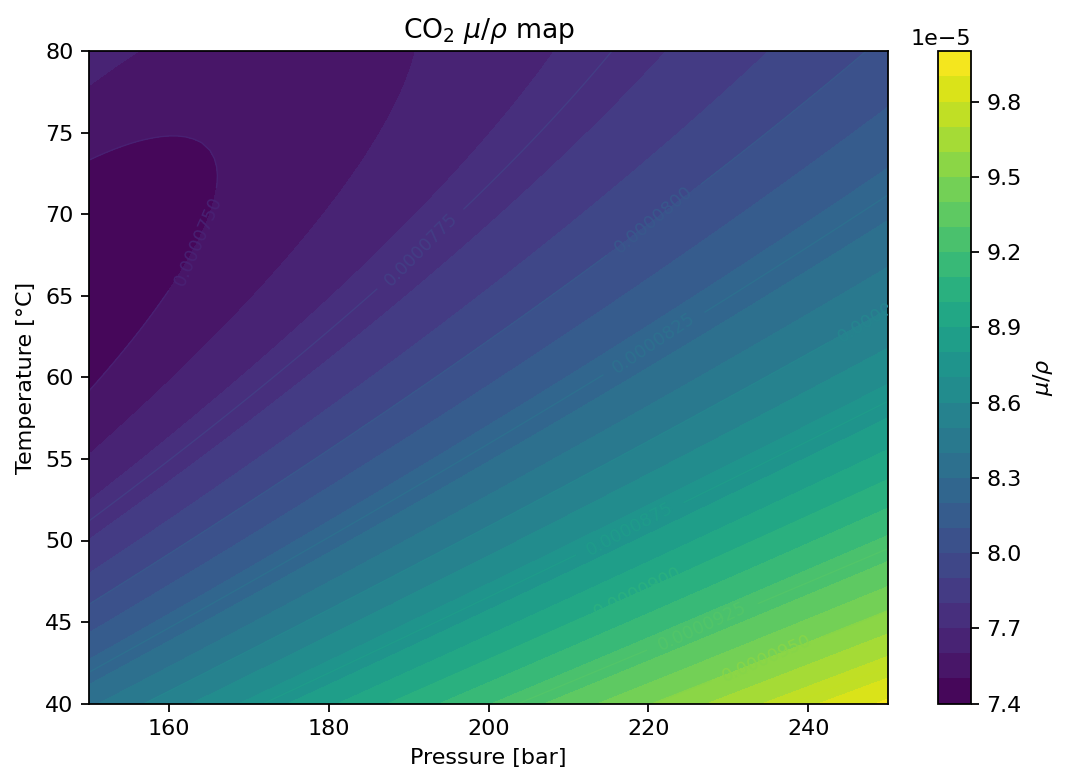

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pc = darts_model.physics.property_containers[0]

P_list = np.linspace(150, 250, 100)              # bar
T_list = np.linspace(40 + 273.15, 80 + 273.15, 80)   # K

results = []

for p in P_list:
    for t in T_list:
        state = [p, t]     # 对你这个单组分 PT setup
        pc.evaluate(state)

        rho = float(pc.dens[0])   # density
        mu = float(pc.mu[0])      # viscosity

        mu_over_rho = mu / rho

        results.append((p, t, rho, mu, mu_over_rho))

df = pd.DataFrame(
    results,
    columns=["P_bar", "T_K", "Density", "Viscosity", "mu_over_rho"]
)

# reshape for plotting
P_unique = np.sort(df["P_bar"].unique())
T_unique = np.sort(df["T_K"].unique())

PP, TT = np.meshgrid(P_unique, T_unique)
MU_OVER_RHO = (
    df.pivot(index="T_K", columns="P_bar", values="mu_over_rho")
      .loc[T_unique, P_unique]
      .values
)

# plot
plt.figure(figsize=(7, 5), dpi=160)
cf = plt.contourf(PP, TT - 273.15, MU_OVER_RHO, levels=25)
plt.colorbar(cf, label=r'$\mu / \rho$')
cs = plt.contour(PP, TT - 273.15, MU_OVER_RHO, levels=10, linewidths=0.6)
plt.clabel(cs, inline=True, fontsize=8)

plt.xlabel("Pressure [bar]")
plt.ylabel("Temperature [°C]")
plt.title(r"CO$_2$ $\mu/\rho$ map")
plt.tight_layout()
plt.show()

In [4]:
# get k values for CO2
pc = darts_model.physics.property_containers[0]
P_list = np.linspace(190, 350, 30)     # bar
T_list = np.linspace(290, 360, 35)     # K
gas_id = pc.phases_name.index("CO2_rich")
aq_id  = pc.phases_name.index("aqueous")
co2_id = pc.components_name.index("CO2")
h2o_id = pc.components_name.index("H2O")

results = []
for P in P_list:
    for T in T_list:
        state = [P, 0.5, T]
        pc.evaluate(state)

        y = pc.x[gas_id, co2_id]
        x = pc.x[aq_id, co2_id]

        K_CO2 = y / max(x, pc.min_z)

        y = pc.x[gas_id, h2o_id]
        x = pc.x[aq_id, h2o_id]

        K_H2O = y / max(x, pc.min_z)

        results.append([P, T, K_CO2, K_H2O])
df = pd.DataFrame(results, columns=["P_bar", "T_K", "K_CO2", "K_H2O"])
print(df)
df.to_csv("K_values.csv", index=False)

      P_bar         T_K      K_CO2     K_H2O
0     190.0  290.000000  34.306465  0.003220
1     190.0  292.058824  35.027924  0.003402
2     190.0  294.117647  35.727149  0.003591
3     190.0  296.176471  36.404169  0.003788
4     190.0  298.235294  37.059073  0.003992
...     ...         ...        ...       ...
1045  350.0  351.764706  39.738769  0.015098
1046  350.0  353.823529  39.713249  0.015753
1047  350.0  355.882353  39.674281  0.016431
1048  350.0  357.941176  39.622338  0.017134
1049  350.0  360.000000  39.557885  0.017861

[1050 rows x 4 columns]


Out-of-range rows: 0


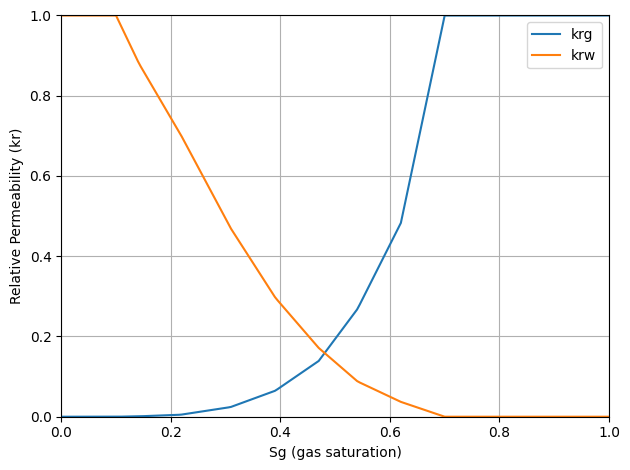

Saved: relperm_check.png


In [6]:
# Get rel_perm values for CO2
rp_g = darts_model.physics.property_containers[0].rel_perm_ev['CO2_rich']   
rp_w = darts_model.physics.property_containers[0].rel_perm_ev['aqueous']  

n = 201
Sg_list = np.linspace(0.0, 1.0, n)
Sw_list = 1.0 - Sg_list

def _to_scalar(v):
    """Handle evaluate() returning scalar or tuple/list."""
    if isinstance(v, (tuple, list, np.ndarray)):
        return float(v[0])
    return float(v)

krg_list = []
krw_list = []

for Sg, Sw in zip(Sg_list, Sw_list):
    krg_list.append(_to_scalar(rp_g.evaluate(Sg)))
    krw_list.append(_to_scalar(rp_w.evaluate(Sw)))

krg_list = np.array(krg_list, dtype=float)
krw_list = np.array(krw_list, dtype=float)


df = pd.DataFrame({
    "Sg": Sg_list,
    "Sw": Sw_list,
    "kr_CO2_rich": krg_list,
    "kr_aqueous": krw_list
})



bad = df[(df["kr_CO2_rich"] < -1e-8) | (df["kr_CO2_rich"] > 1+1e-8) |
         (df["kr_aqueous"]  < -1e-8) | (df["kr_aqueous"]  > 1+1e-8)]
print(f"Out-of-range rows: {len(bad)}")
if len(bad) > 0:
    print(bad.head(20))


plt.figure()
plt.plot(Sg_list, krg_list, label="krg")
plt.plot(Sg_list, krw_list, label="krw")
plt.xlabel("Sg (gas saturation)")
plt.ylabel("Relative Permeability (kr)")
plt.ylim(0, 1) 
plt.xlim(0,1)
plt.grid(True)
plt.legend()
# plt.title("RelPerm check (using evaluators)")
plt.tight_layout()
plt.show()

print("Saved: relperm_check.png")

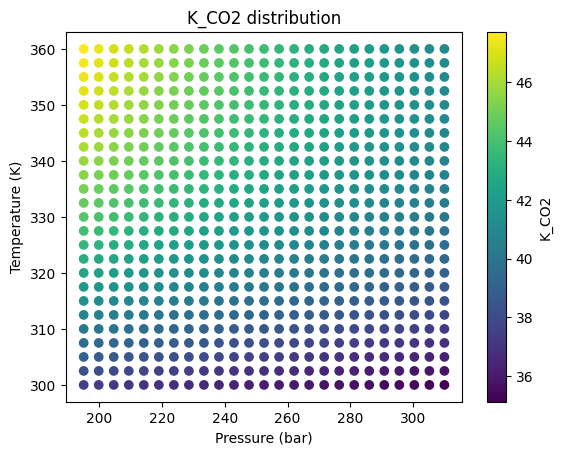

In [13]:
df = pd.read_csv("K_CO2_0.05.csv")
plt.figure()

plt.scatter(
    df["P_bar"],
    df["T_K"],
    c=df["K_CO2"],
)

plt.xlabel("Pressure (bar)")
plt.ylabel("Temperature (K)")
plt.title("K_CO2 distribution")

plt.colorbar(label="K_CO2")

plt.show()

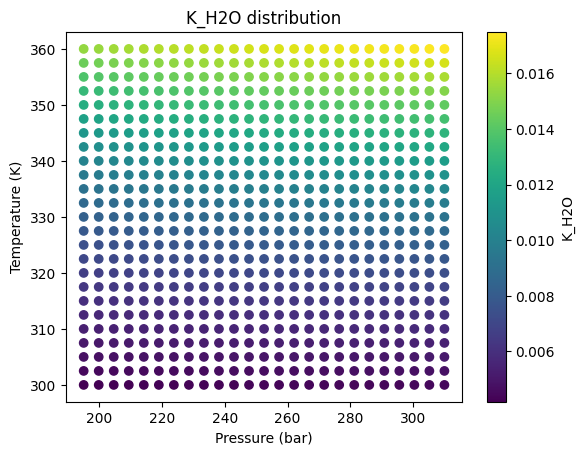

In [6]:
df = pd.read_csv("K_H2O_0.1.csv")
plt.figure()

plt.scatter(
    df["P_bar"],
    df["T_K"],
    c=df["K_H2O"],
)

plt.xlabel("Pressure (bar)")
plt.ylabel("Temperature (K)")
plt.title("K_H2O distribution")

plt.colorbar(label="K_H2O")

plt.show()

darts-package built on 26/01/2026 01:23:46 by SRV554$@SRV554 from 4d3f3e4
Building connection list...
Applying ACTNUM...
Inactive blocks due to ACTNUM:  50
Inactive blocks due to volume:  0
Inactive connections due to transmissibility:  0
Inactive connections total:  255
Inactive blocks due to inactive connections:  0
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Building connection list...
Applying ACTNUM...
Inactive blocks due to ACTNUM:  0
Inactive blocks due to volume:  0
Inact

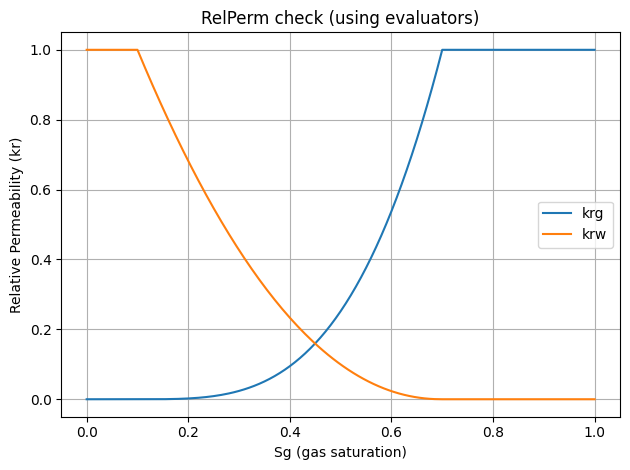

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from model_consK import Model
from darts.engines import value_vector, redirect_darts_output
from darts.physics.base.operators_base import PropertyOperators as props
from output import get_physics_field, plot_xz_section, plot_well_time_data_2, plot_xy_plane
from darts.engines import well_control_iface
def make_cfg_lgr():
    cfg = {
        "grid":{
            "nx" : 50,
            "ny" : 50,
            "dx" :100,
            "dy" :100,
            "nz_res" : 10,
            "dz_res" : 20.0,
            "reservoir_top" : 2000,
        },
        "burden":{
            "over_thickness":2000,
            "under_thickness":2000,
            "dz_ratio" : 2,
            "poro_burden" : 0.0001,
            "perm_burden" : 1e-6,

        },
        "rock":{
            "perm_x":50, "perm_y" :50, "perm_z" : 50,
            "poro" : 0.1,
            "rcond_res" : 181.44, "hcap_res":2650.0,
            "rcond_over":149.54, "hcap_over":2347.29,
            "rcond_under" : 149.54, "hcap_under":2347.29,
        },

        "lgrs":{
            "lgr0":{
                "parent_grid_name": "global",
                "lgr_coords_in_parent_grid" :{"i_range": [26, 26],
                                                "j_range": [26, 26],
                                                "k_range": [1, 10],
                                                "refine": [7, 7, 1],
                                                "tag" : "inj"

                }
            },
            "lgr1":{
                "parent_grid_name": "global",
                "lgr_coords_in_parent_grid" :{"i_range": [21, 21],
                                                "j_range": [31, 31],
                                                "k_range": [1, 10],
                                                "refine": [7, 7, 1],
                                                "tag" : "prod"

                }
            },
            "lgr2":{
                "parent_grid_name": "global",
                "lgr_coords_in_parent_grid" :{"i_range": [31, 31],
                                                "j_range": [31, 31],
                                                "k_range": [1, 10],
                                                "refine": [7, 7, 1],
                                                "tag" : "prod"

                }
            },
            "lgr3":{
                "parent_grid_name": "global",
                "lgr_coords_in_parent_grid" :{"i_range": [21, 21],
                                                "j_range": [21, 21],
                                                "k_range": [1, 10],
                                                "refine": [7, 7, 1],
                                                "tag" : "prod"

                }
            },
            "lgr4":{
                "parent_grid_name": "global",
                "lgr_coords_in_parent_grid" :{"i_range": [31, 31],
                                                "j_range": [21, 21],
                                                "k_range": [1, 10],
                                                "refine": [7, 7, 1],
                                                "tag" : "prod"

                }
            }   
        },

        "wells":{
           "I1": {"lgr": "lgr0", "k_from": 1, "k_to": 10},
           "P1": {"lgr": "lgr1", "k_from": 1, "k_to": 5},
           "P2": {"lgr": "lgr2", "k_from": 1, "k_to": 5},
           "P3": {"lgr": "lgr3", "k_from": 1, "k_to": 5},
           "P4": {"lgr": "lgr4", "k_from": 1, "k_to": 5},
        },
    }
    return cfg
USE_LGR=True
if __name__ == '__main__':
    if USE_LGR:
        cfg = make_cfg_lgr()
        darts_model = Model(cfg)
    else:
        darts_model = Model()

    # darts_model.params.linear_type = darts_model.params.linear_solver_t.cpu_superlu
    redirect_darts_output('run.log')
    darts_model.init(platform="cpu") # cpu or GPU, PLATFORM
    darts_model.set_output()

# Get rel_perm values for CO2
rp_g = darts_model.physics.property_containers[0].rel_perm_ev['CO2_rich']   
rp_w = darts_model.physics.property_containers[0].rel_perm_ev['aqueous']  
# --- 2) 采样饱和度 ---
n = 201
Sg_list = np.linspace(0.0, 1.0, n)
Sw_list = 1.0 - Sg_list

def _to_scalar(v):
    """Handle evaluate() returning scalar or tuple/list."""
    if isinstance(v, (tuple, list, np.ndarray)):
        return float(v[0])
    return float(v)

krg_list = []
krw_list = []

for Sg, Sw in zip(Sg_list, Sw_list):
    krg_list.append(_to_scalar(rp_g.evaluate(Sg)))
    krw_list.append(_to_scalar(rp_w.evaluate(Sw)))

krg_list = np.array(krg_list, dtype=float)
krw_list = np.array(krw_list, dtype=float)

# --- 3) 导出数据（可选但强烈建议）---
df = pd.DataFrame({
    "Sg": Sg_list,
    "Sw": Sw_list,
    "kr_CO2_rich": krg_list,
    "kr_aqueous": krw_list
})


# --- 4) 快速数值体检 ---
bad = df[(df["kr_CO2_rich"] < -1e-8) | (df["kr_CO2_rich"] > 1+1e-8) |
         (df["kr_aqueous"]  < -1e-8) | (df["kr_aqueous"]  > 1+1e-8)]
print(f"Out-of-range rows: {len(bad)}")
if len(bad) > 0:
    print(bad.head(20))

# --- 5) 画图：kr vs saturation ---
plt.figure()
plt.plot(Sg_list, krg_list, label="krg")
plt.plot(Sg_list, krw_list, label="krw")
plt.xlabel("Sg (gas saturation)")
plt.ylabel("Relative Permeability (kr)")
plt.ylim(-0.05, 1.05)  # 方便看是否越界
plt.grid(True)
plt.legend()
plt.title("RelPerm check (using evaluators)")
plt.tight_layout()
plt.show()


In [23]:
import h5py

h5_path = r"C:\Users\ZEHIR\Downloads\well_data.h5"

def print_h5_tree(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"[D] {name}  shape={obj.shape}  dtype={obj.dtype}")
    else:
        print(f"[G] {name}")

with h5py.File(h5_path, "r") as f:
    var_names = list(f["dynamic/variable_names"][:])
    # bytes -> str
    var_names = [v.decode("utf-8") if isinstance(v, (bytes, np.bytes_)) else str(v) for v in var_names]
    print("variable_names:", var_names)
    print("X shape:", f["dynamic/X"].shape)
    print("time shape:", f["dynamic/time"].shape)
    print("cell_id shape:", f["dynamic/cell_id"].shape)

variable_names: ['pressure', 'CO2', 'temperature']
X shape: (2995, 130, 3)
time shape: (2995,)
cell_id shape: (130,)


In [24]:
import os
import numpy as np
import pandas as pd

from fine_homo_egg import Model
from darts.engines import value_vector, redirect_darts_output
from darts.physics.base.operators_base import PropertyOperators as props
from output import get_physics_field, plot_xy_plane, plot_xz_section, plot_well_time_data_2, plot_average_res_pressure
from Auxiliary_functions import calculate_total_co2_in_reservoir_single_phase, print_cell_connectivity, summarize_patch_boundary_T

def make_cfg_lgr():
    cfg = {
        "burden":{
            "over_thickness":2000,
            "under_thickness":2000,
            "poro_burden" : 1e-5,
            "perm_burden" : 1e-9,
            "rcond_over":149.54, "hcap_over":2347.29,
            "rcond_under" : 149.54, "hcap_under":2347.29,
        },

        "lgrs":{
            "lgr0":{
                "parent_grid_name": "global",
                "lgr_coords_in_parent_grid" :{"i_range": [46, 46],
                                                "j_range": [30, 30],
                                                "k_range": [1, 7],
                                                "refine": [5, 5, 1],
                                                "tag" : "inj"

                }
            },
            "lgr1":{
                "parent_grid_name": "global",
                "lgr_coords_in_parent_grid" :{"i_range": [16, 16],
                                                "j_range": [30, 30],
                                                "k_range": [1, 7],
                                                "refine": [5, 5, 1],
                                                "tag" : "prod"

                }
            }
        },
        "wells":{
           "I1": {"lgr": "lgr0", "k_from": 1, "k_to": 7},
           "P1": {"lgr": "lgr1", "k_from": 1, "k_to": 7},
        }
    }
    return cfg

def cal_average_res_pre(m):
    n_res = m.reservoir.mesh.n_res_blocks
    n_vars = len(m.physics.vars)

    X = np.asarray(m.physics.engine.X, dtype=float)
    P = X.reshape((-1, n_vars))[:n_res, 0]

    poro = np.array(m.reservoir.mesh.poro, copy=False)[:n_res]
    volume = np.array(m.reservoir.mesh.volume, copy=False)[:n_res]

    pv = poro * volume
    return float(np.sum(P * pv) / np.sum(pv))

USE_LGR=False

Nt = 1
Dt = 30
output_dir = r".\output_fine_test"
FIG_DIR = os.path.join(output_dir, "figures")
SECTION_DIR = os.path.join(FIG_DIR, "sections")
WELL_DIR = os.path.join(FIG_DIR, "well_time_plots")
os.makedirs(SECTION_DIR, exist_ok=True)
os.makedirs(WELL_DIR, exist_ok=True)

if __name__ == '__main__':
    if USE_LGR:
        cfg = make_cfg_lgr()
        darts_model = Model(cfg)
    else:
        darts_model = Model()
   

    redirect_darts_output('run.log')
    darts_model.init(platform="cpu")
    darts_model.set_output(output_folder='output_fine_test')

   

    tot_pv = np.sum(np.array(darts_model.reservoir.mesh.poro) * np.array(darts_model.reservoir.mesh.volume))
    print(f"Total pore volume: {tot_pv:.6e} STB")

   
    avg_p_value = []
    avg_p_time = []
     #plot initial condition
    prim0 = get_physics_field(darts_model)
    avg_p_time.append(float(darts_model.physics.engine.t))
    avg_p_value.append(cal_average_res_pre(darts_model))
    
    prim0 = get_physics_field(darts_model)
    

    Tmin = 41 + 273.15
    Tmax = 80+ 273.15
    if True:
        for t in range(Nt):
            darts_model.run(Dt)
            

            darts_model.print_timers()
            darts_model.print_stat()
            
            t_end = float(darts_model.physics.engine.t)
            avg_p_time.append(t_end)
            avg_p_value.append(cal_average_res_pre(darts_model))
            prim = get_physics_field(darts_model)
            print("vars:", list(prim.keys()))
            for k in prim.keys():
                if "temp" in k.lower() or "temperature" in k.lower():
                    plot_xz_section(darts_model, prim[k], use_lgr=USE_LGR, zmin=1990, zmax=2080,
                                    savepath=os.path.join(SECTION_DIR, f"coarse_section_T_{t_end}_injector.png"),
                                    title=k,vmin=Tmin, vmax=Tmax, edgecolor="none", linewidth=0.0,
                                    logscale=False)
                    
                    plot_xz_section(darts_model, prim[k], use_lgr=USE_LGR, zmin=1990, zmax=2080,
                                    y0=1365,savepath=os.path.join(SECTION_DIR, f"coarse_section_T_{t_end}_producer.png"),
                                    title=k,vmin=Tmin, vmax=Tmax, edgecolor="none", linewidth=0.0,
                                    logscale=False)
                    
                    break
        # compute well time data
        time_data_dict = darts_model.output.store_well_time_data(save_output_files=True)
        time_data_df = pd.DataFrame.from_dict(time_data_dict)



        

darts-package built on 26/01/2026 01:23:46 by SRV554$@SRV554 from 4d3f3e4
Building connection list...
Applying ACTNUM...
Inactive blocks due to ACTNUM:  0
Inactive blocks due to volume:  0
Inactive connections due to transmissibility:  0
Inactive connections total:  0
Inactive blocks due to inactive connections:  0
Building connection list...
Applying ACTNUM...
Inactive blocks due to ACTNUM:  0
Inactive blocks due to volume:  0
Inactive connections due to transmissibility:  0
Inactive connections total:  0
Inactive blocks due to inactive connections:  0
Building connection list...
Applying ACTNUM...
Inactive blocks due to ACTNUM:  0
Inactive blocks due to volume:  0
Inactive connections due to transmissibility:  0
Inactive connections total:  0
Inactive blocks due to inactive connections:  0
Simulation parameters:
	 eta = [1.e+20 1.e+20]
	 dt_first = 1e-06
	 dt_min = 1e-15
	 dt_mult = 2
	 dt_max = 30
	 newton_tol = 0.001
	 newton_tol_wel_mult = 100.0
	 newton_tol_stationary = 0.001
	 n

In [20]:
import numpy as np
import pandas as pd


def _to_numpy(vec, dtype=None):
    arr = np.asarray(vec)
    if dtype is not None:
        arr = arr.astype(dtype, copy=False)
    return arr


def get_connection_arrays(darts_model):
    mesh = darts_model.reservoir.mesh
    block_m = _to_numpy(mesh.block_m, dtype=int)
    block_p = _to_numpy(mesh.block_p, dtype=int)
    tran = _to_numpy(mesh.tran, dtype=float)
    return block_m, block_p, tran


def get_pressure_array(darts_model, reservoir_only=True):
    n_vars = len(darts_model.physics.vars)
    X = _to_numpy(darts_model.physics.engine.X, dtype=float).reshape((-1, n_vars))

    pressure = X[:, 0].copy()

    if reservoir_only:
        if hasattr(darts_model.reservoir.mesh, "n_res_blocks"):
            n_res = int(darts_model.reservoir.mesh.n_res_blocks)
        else:
            n_res = int(darts_model.reservoir.n)
        pressure = pressure[:n_res]

    return pressure


def build_connection_dataframe(darts_model, include_pressure=False):
    block_m, block_p, tran = get_connection_arrays(darts_model)

    df = pd.DataFrame({
        "conn_id": np.arange(len(block_m), dtype=int),
        "block_m": block_m,
        "block_p": block_p,
        "tran": tran,
    })

    if include_pressure:
        pressure = get_pressure_array(darts_model, reservoir_only=True)
        n_res = len(pressure)

        # 哪些端点是合法 reservoir index
        valid_m = (block_m >= 0) & (block_m < n_res)
        valid_p = (block_p >= 0) & (block_p < n_res)
        valid_rr = valid_m & valid_p

        df["is_res_m"] = valid_m
        df["is_res_p"] = valid_p
        df["is_res_res"] = valid_rr

        # 先全部填 NaN
        df["pressure_m"] = np.nan
        df["pressure_p"] = np.nan
        df["dp_m_minus_p"] = np.nan

        # 只对 reservoir-reservoir connection 赋值
        if np.any(valid_rr):
            df.loc[valid_rr, "pressure_m"] = pressure[block_m[valid_rr]]
            df.loc[valid_rr, "pressure_p"] = pressure[block_p[valid_rr]]
            df.loc[valid_rr, "dp_m_minus_p"] = (
                df.loc[valid_rr, "pressure_m"] - df.loc[valid_rr, "pressure_p"]
            )

    return df


def find_connection_between_two_cells(darts_model, cell_a, cell_b, include_pressure=False):
    df = build_connection_dataframe(darts_model, include_pressure=include_pressure)

    mask = (
        ((df["block_m"] == cell_a) & (df["block_p"] == cell_b)) |
        ((df["block_m"] == cell_b) & (df["block_p"] == cell_a))
    )

    return df.loc[mask].reset_index(drop=True)


def get_pressure_of_cell(darts_model, cell_idx):
    pressure = get_pressure_array(darts_model, reservoir_only=True)
    if cell_idx < 0 or cell_idx >= len(pressure):
        raise IndexError(f"cell_idx={cell_idx} 超出 reservoir pressure 范围 0~{len(pressure)-1}")
    return float(pressure[cell_idx])


def get_tran_between_two_cells(darts_model, cell_a, cell_b):
    df = find_connection_between_two_cells(
        darts_model, cell_a, cell_b, include_pressure=False
    )

    if df.empty:
        return {
            "found": False,
            "n_connections": 0,
            "tran": None,
            "dataframe": df,
        }

    return {
        "found": True,
        "n_connections": len(df),
        "tran": df["tran"].to_numpy(dtype=float),
        "dataframe": df,
    }


def get_pressure_and_tran_for_two_cells(darts_model, cell_a, cell_b):
    p_a = get_pressure_of_cell(darts_model, cell_a)
    p_b = get_pressure_of_cell(darts_model, cell_b)
    conn_info = get_tran_between_two_cells(darts_model, cell_a, cell_b)

    return {
        "cell_a": int(cell_a),
        "pressure_a": float(p_a),
        "cell_b": int(cell_b),
        "pressure_b": float(p_b),
        "dp_a_minus_b": float(p_a - p_b),
        "connection_found": conn_info["found"],
        "n_connections": conn_info["n_connections"],
        "tran": conn_info["tran"],
        "connection_df": conn_info["dataframe"],
    }

def flux_calculation(darts_model, cell_a, cell_b):
    info = get_pressure_and_tran_for_two_cells(darts_model, cell_a, cell_b)

    if not info["connection_found"]:
        raise ValueError(f"Cells {cell_a} and {cell_b} are not connected.")

    # For simplicity, assume single connection if multiple exist
    tran = info["tran"][0]
    dp = info["dp_a_minus_b"]

    n_vars = len(darts_model.physics.vars)

    X = np.asarray(darts_model.physics.engine.X, dtype=float).reshape((-1, n_vars))

    cell_idx = cell_a
    state = X[cell_idx, :].copy()

    pc = darts_model.physics.property_containers[0]
    pc.evaluate(state)

    print("pressure =", state[0])
    print("mu =", pc.mu[0])
    print("rho =", pc.dens[0])
    mu = float(pc.mu[0])  # viscosity
    
    # Darcy's law: q = -T * dp * lambda
    flux = -tran * dp / mu

    return {
        "cell_a": info["cell_a"],
        "pressure_a": info["pressure_a"],
        "cell_b": info["cell_b"],
        "pressure_b": info["pressure_b"],
        "dp_a_minus_b": info["dp_a_minus_b"],
        "tran": tran,
        "flux": flux,
        "viscosity": mu
    }

def find_all_connections_of_cell(darts_model, cell_idx):
    block_m, block_p, tran = get_connection_arrays(darts_model)

    df = pd.DataFrame({
        "conn_id": np.arange(len(block_m), dtype=int),
        "block_m": block_m,
        "block_p": block_p,
        "tran": tran,
    })

    mask = (df["block_m"] == cell_idx) | (df["block_p"] == cell_idx)
    out = df.loc[mask].copy()

    if out.empty:
        return out.reset_index(drop=True)

    out["neighbor"] = np.where(out["block_m"] == cell_idx, out["block_p"], out["block_m"])
    return out.reset_index(drop=True)

def get_pressures_of_cells(darts_model, cell_indices):
    """
    批量查询多个 cell 的 pressure

    Parameters
    ----------
    cell_indices : list[int] or np.ndarray

    Returns
    -------
    df : pd.DataFrame
        columns = ['cell_idx', 'pressure']
    """
    pressure = get_pressure_array(darts_model, reservoir_only=True)
    cell_indices = np.asarray(cell_indices, dtype=int)

    if np.any(cell_indices < 0) or np.any(cell_indices >= len(pressure)):
        raise IndexError("cell_indices 中存在超出 pressure 数组范围的 index")

    df = pd.DataFrame({
        "cell_idx": cell_indices,
        "pressure": pressure[cell_indices]
    })
    return df

In [16]:
import numpy as np

NX = 300
NY = 300

def lin_index(i0, j0, k0, nx=NX, ny=NY):
    return i0 + j0 * nx + k0 * nx * ny

def block_indices(i_center_1b, j_center_1b, k0, kind="patch"):
    """
    kind:
        - "patch": 5x5 LGR patch
        - "left_nb", "right_nb", "up_nb", "down_nb": adjacent coarse-neighbor 5x5 block
        - "left_if", "right_if", "up_if", "down_if": patch internal interface side (5 cells)
    """
    ic = i_center_1b - 1   # -> 0-based center
    jc = j_center_1b - 1

    # patch range in 0-based
    i0_min = ic - 2
    i0_max = ic + 2
    j0_min = jc - 2
    j0_max = jc + 2

    ids = []

    if kind == "patch":
        for j0 in range(j0_min, j0_max + 1):
            for i0 in range(i0_min, i0_max + 1):
                ids.append(lin_index(i0, j0, k0))

    elif kind == "left_if":
        i0 = i0_min
        for j0 in range(j0_min, j0_max + 1):
            ids.append(lin_index(i0, j0, k0))

    elif kind == "right_if":
        i0 = i0_max
        for j0 in range(j0_min, j0_max + 1):
            ids.append(lin_index(i0, j0, k0))

    elif kind == "up_if":
        j0 = j0_min
        for i0 in range(i0_min, i0_max + 1):
            ids.append(lin_index(i0, j0, k0))

    elif kind == "down_if":
        j0 = j0_max
        for i0 in range(i0_min, i0_max + 1):
            ids.append(lin_index(i0, j0, k0))

    elif kind == "left_nb":
        for j0 in range(j0_min, j0_max + 1):
            for i0 in range(i0_min - 5, i0_min):
                ids.append(lin_index(i0, j0, k0))

    elif kind == "right_nb":
        for j0 in range(j0_min, j0_max + 1):
            for i0 in range(i0_max + 1, i0_max + 6):
                ids.append(lin_index(i0, j0, k0))

    elif kind == "up_nb":
        for j0 in range(j0_min - 5, j0_min):
            for i0 in range(i0_min, i0_max + 1):
                ids.append(lin_index(i0, j0, k0))

    elif kind == "down_nb":
        for j0 in range(j0_max + 1, j0_max + 6):
            for i0 in range(i0_min, i0_max + 1):
                ids.append(lin_index(i0, j0, k0))

    else:
        raise ValueError(f"Unknown kind: {kind}")

    return ids

In [25]:
k0 = 1  # reservoir top layer

inj_left_if = block_indices(226, 150, k0, "left_if")
inj_left_nb = block_indices(226, 150, k0, "left_nb")

print("injector 左侧 interface 内侧:", inj_left_if)
print("injector 左侧 coarse neighbor 对应块:", inj_left_nb)

injector 左侧 interface 内侧: [134323, 134623, 134923, 135223, 135523]
injector 左侧 coarse neighbor 对应块: [134318, 134319, 134320, 134321, 134322, 134618, 134619, 134620, 134621, 134622, 134918, 134919, 134920, 134921, 134922, 135218, 135219, 135220, 135221, 135222, 135518, 135519, 135520, 135521, 135522]


In [31]:
p = get_pressures_of_cells(darts_model, inj_left_nb)

p_ave_left = p['pressure'].mean()
print("Average pressure (left grid):", p_ave_left)


p = get_pressures_of_cells(darts_model, inj_left_if)
p_ave_right = p['pressure'].mean()

print("interface pressure:", p)

q1 = flux_calculation(darts_model, cell_a=134323, cell_b=134322)
q2 = flux_calculation(darts_model, cell_a=134623, cell_b=134622)
q3 = flux_calculation(darts_model, cell_a=134923, cell_b=134922)
q4 = flux_calculation(darts_model, cell_a=135223, cell_b=135222)
q5 = flux_calculation(darts_model, cell_a=135523, cell_b=135522)
print("Fluxes:", q1["flux"], q2["flux"], q3["flux"], q4["flux"], q5["flux"])
T1_eff = q1["flux"] * q1["viscosity"] / (p_ave_left - p["pressure"].iloc[0])
T2_eff = q2["flux"] * q2["viscosity"] / (p_ave_left - p["pressure"].iloc[1])
T3_eff = q3["flux"] * q3["viscosity"] / (p_ave_left - p["pressure"].iloc[2])
T4_eff = q4["flux"] * q4["viscosity"] / (p_ave_left - p["pressure"].iloc[3])
T5_eff = q5["flux"] * q5["viscosity"] / (p_ave_left - p["pressure"].iloc[4])
T_eff = (T1_eff + T2_eff + T3_eff + T4_eff + T5_eff) / 5
print("Effective transmissibilities:", T_eff)

tot_q = q1["flux"] + q2["flux"] + q3["flux"] + q4["flux"] + q5["flux"]
print("Total flux:", tot_q)

T_eff = tot_q * q1["viscosity"] / (p_ave_left - p_ave_right) /5
print("Effective transmissibility of the interface:", T_eff)

Average pressure (left grid): 204.99696411828845
interface pressure:    cell_idx    pressure
0    134323  206.379473
1    134623  206.963716
2    134923  207.324451
3    135223  206.963669
4    135523  206.379380
pressure = 206.37947251678222
mu = 0.07687757317542766
rho = 832.2608915026375
pressure = 206.96371636684475
mu = 0.0773576001821841
rho = 834.797208865949
pressure = 207.3244506338463
mu = 0.07757676598475556
rho = 835.9458665606526
pressure = 206.96366894376138
mu = 0.07735759945173688
rho = 834.7972058786896
pressure = 206.37937962979535
mu = 0.07687759514139135
rho = 832.2610104020974
Fluxes: -66.32628795976012 -93.40926098372765 -115.66890446983508 -93.40919908334341 -66.32635690340838
Effective transmissibilities: 3.716037503901088
Total flux: -435.1400094000747
Effective transmissibility of the interface: 3.7062928206887626


In [ ]:
import re
import numpy as np
import pandas as pd
from pathlib import Path


def read_ecl_keyword(filepath, keyword, expected_len=None):
    """
    Read one keyword block from an Eclipse-style INC file.

    Supports lines like:
        PERMX
        100 200 300 /
    and repeated-value syntax like:
        10*100.0
    """
    keyword = keyword.upper()
    values = []
    in_block = False

    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        for raw_line in f:
            line = raw_line.strip()

            if not line:
                continue

            # remove comments after --
            if "--" in line:
                line = line.split("--", 1)[0].strip()
                if not line:
                    continue

            upper = line.upper()

            if not in_block:
                if upper.startswith(keyword):
                    in_block = True
                    rest = line[len(keyword):].strip()
                    if rest:
                        tokens = rest.replace(",", " ").split()
                    else:
                        tokens = []
                else:
                    continue
            else:
                tokens = line.replace(",", " ").split()

            for tok in tokens:
                if tok == "/":
                    in_block = False
                    break

                # repeated syntax: 10*123.4
                if "*" in tok:
                    n_str, v_str = tok.split("*", 1)
                    n = int(n_str)
                    v = float(v_str)
                    values.extend([v] * n)
                else:
                    values.append(float(tok))

            if not in_block:
                break

    arr = np.asarray(values, dtype=float)

    if expected_len is not None and len(arr) != expected_len:
        raise ValueError(
            f"{filepath.name}: keyword {keyword} length = {len(arr)}, expected {expected_len}"
        )

    return arr


def lorenz_from_perm(k):
    """
    Lorenz coefficient for the special case:
    - constant phi
    - constant thickness h
    - equal cell volume

    Steps follow your TU Delft slide definition:
    1) sort descending by flow capacity (here equivalent to k)
    2) cumulative flow capacity F
    3) cumulative storage capacity Phi = cumulative cell fraction
    4) Lc = 2 * area between F(Phi) and diagonal
    """
    k = np.asarray(k, dtype=float).ravel()

    # optional: ignore non-positive / inactive values
    k = k[np.isfinite(k)]
    k = k[k > 0]

    if k.size == 0:
        raise ValueError("No positive permeability values found.")

    # descending order, consistent with your slide
    k_sorted = np.sort(k)[::-1]

    n = k_sorted.size
    F = np.concatenate(([0.0], np.cumsum(k_sorted) / np.sum(k_sorted)))
    Phi = np.linspace(0.0, 1.0, n + 1)

    # area between curve and diagonal
    area_curve = np.trapz(F, Phi)
    area_diag = 0.5
    Lc = 2.0 * abs(area_curve - area_diag)

    return Lc, Phi, F


def extract_realization_id(filename):
    """
    Extract number from names like PERM1_ECL.INC, PERM15_ECL.INC
    """
    m = re.search(r"PERM(\d+)", filename.upper())
    return int(m.group(1)) if m else None


def batch_lorenz_from_folder(folder, keyword="PERMX", expected_len=None, save_csv=True):
    folder = Path(folder)

    files = sorted(folder.glob("PERM*_ECL.INC"))
    if not files:
        raise FileNotFoundError(f"No files matched PERM*_ECL.INC in {folder}")

    rows = []

    for fp in files:
        rid = extract_realization_id(fp.name)

        try:
            k = read_ecl_keyword(fp, keyword=keyword, expected_len=expected_len)
            lc, Phi, F = lorenz_from_perm(k)

            rows.append({
                "realization": rid,
                "file": fp.name,
                "keyword": keyword,
                "n_cells": len(k),
                "Lc": lc,
                "k_mean": float(np.mean(k)),
                "k_std": float(np.std(k)),
                "k_min": float(np.min(k)),
                "k_max": float(np.max(k)),
            })

        except Exception as e:
            rows.append({
                "realization": rid,
                "file": fp.name,
                "keyword": keyword,
                "n_cells": np.nan,
                "Lc": np.nan,
                "k_mean": np.nan,
                "k_std": np.nan,
                "k_min": np.nan,
                "k_max": np.nan,
                "error": str(e),
            })

    df = pd.DataFrame(rows).sort_values(by="realization", na_position="last").reset_index(drop=True)

    if save_csv:
        out_csv = folder / f"lorenz_summary_{keyword}.csv"
        df.to_csv(out_csv, index=False)
        print(f"Saved summary to: {out_csv}")

    return df


if __name__ == "__main__":
    folder = r"E:\data\Egg_Model_Data_Files_v2\Permeability_Realizations"

    # 60*60*7 = 25200 reservoir cells for your Egg reservoir part
    df = batch_lorenz_from_folder(
        folder=folder,
        keyword="PERMX",
        expected_len=60 * 60 * 7,
        save_csv=True,
    )

    print(df[["realization", "file", "Lc"]])